In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils/preprocessing.py
/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils/features.py
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [2]:
!pip install dagshub mlflow xgboost optuna -q

import sys
import xgboost as xgb
import mlflow
import mlflow.xgboost
import dagshub
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from kaggle_secrets import UserSecretsClient

optuna.logging.set_verbosity(optuna.logging.WARNING)

dagshub.init(repo_owner='lshek22', repo_name='walmart-recruiting-store-sales-forecasting', mlflow=True)



print("XGBoost version:", xgb.__version__)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 72.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 62.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9172c71c-93a4-47ed-a6e7-24ca9e5e72b4&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=1d8fdb9082677d91c746324bfa27c767aaca1f025706ca0f603841695a8bcd34




Accessing as lshek22

Initialized MLflow to track repo "lshek22/walmart-recruiting-store-sales-forecasting"

Repository lshek22/walmart-recruiting-store-sales-forecasting initialized!

XGBoost version: 3.2.0
MLflow tracking URI: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow


/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils/preprocessing.py
/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils/features.py
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip
train.csv    shape: 421,570 rows × 5 columns
test.csv     shape: 115,064 rows × 4 columns
stores.csv   shape: 45 rows × 3 columns
features.csv shape: 8,190 rows × 12 columns
Train columns:    ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
Test columns:     ['Store', 'Dept', 'Date', 'IsHoliday']
Stores columns:   ['Store', 'Type', 'Size']
Features columns: ['Store', 'Date', 'Temperature', 'Fuel_Price'

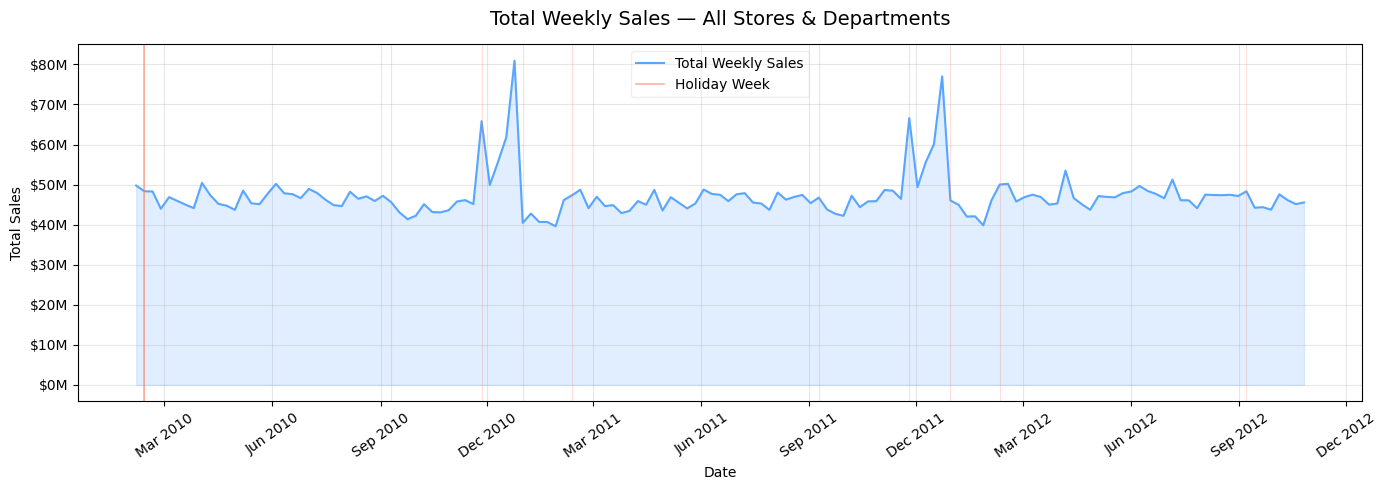

sales_over_time.png saved successfully!
holiday name mapping complete: ['None' 'Super Bowl' 'Labor Day' 'Thanksgiving' 'Christmas']


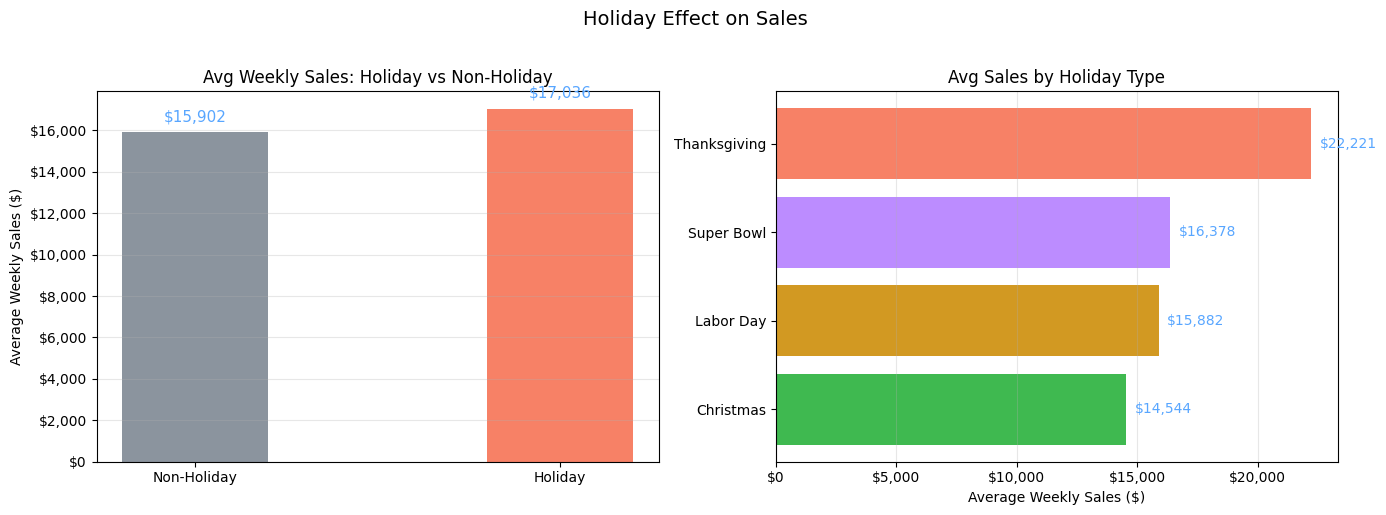

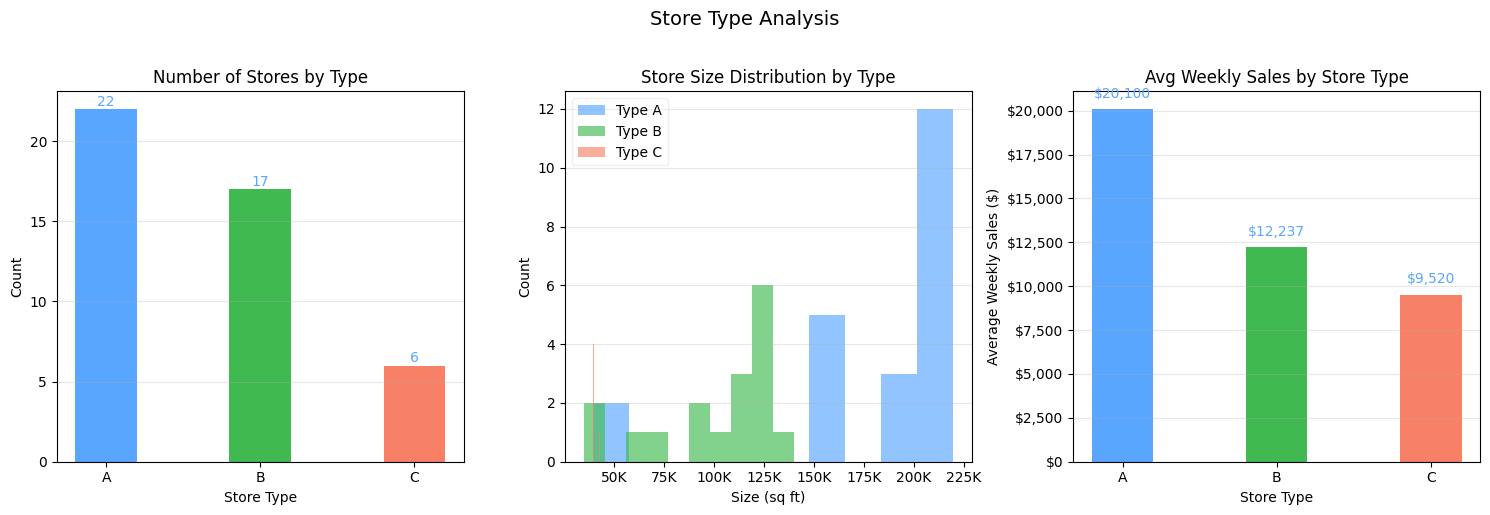

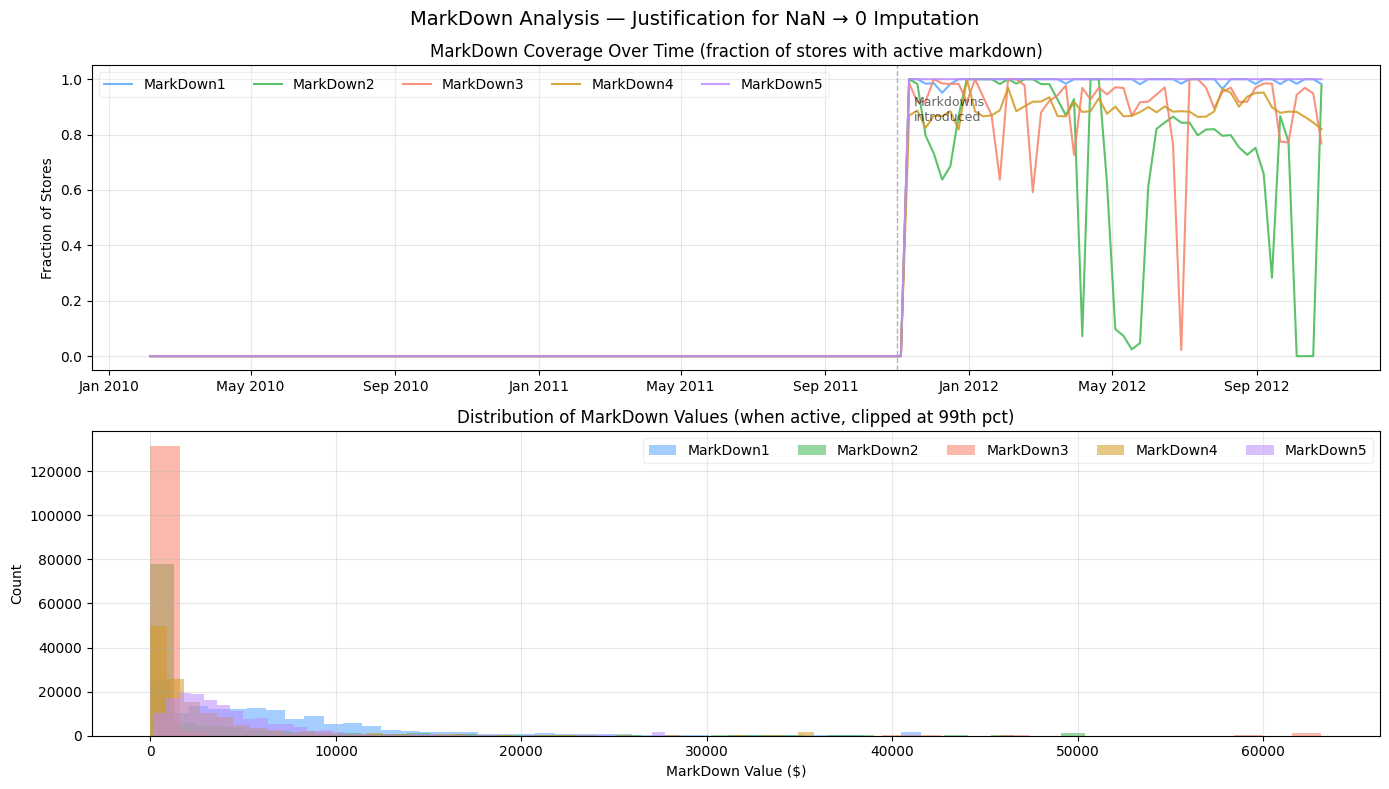

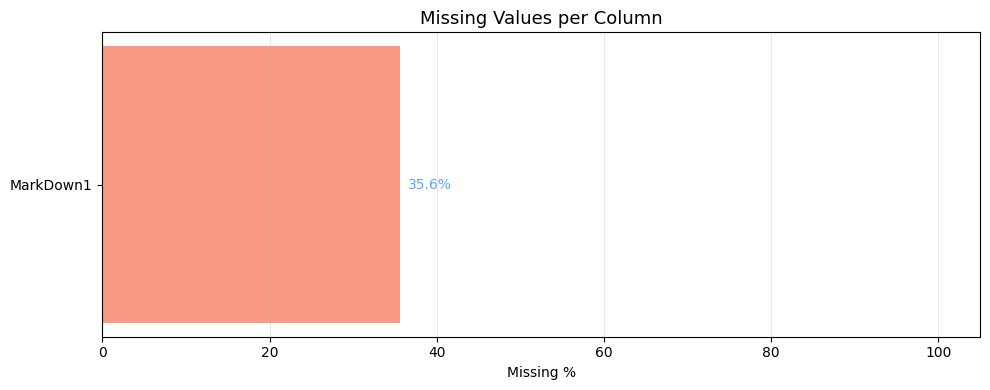

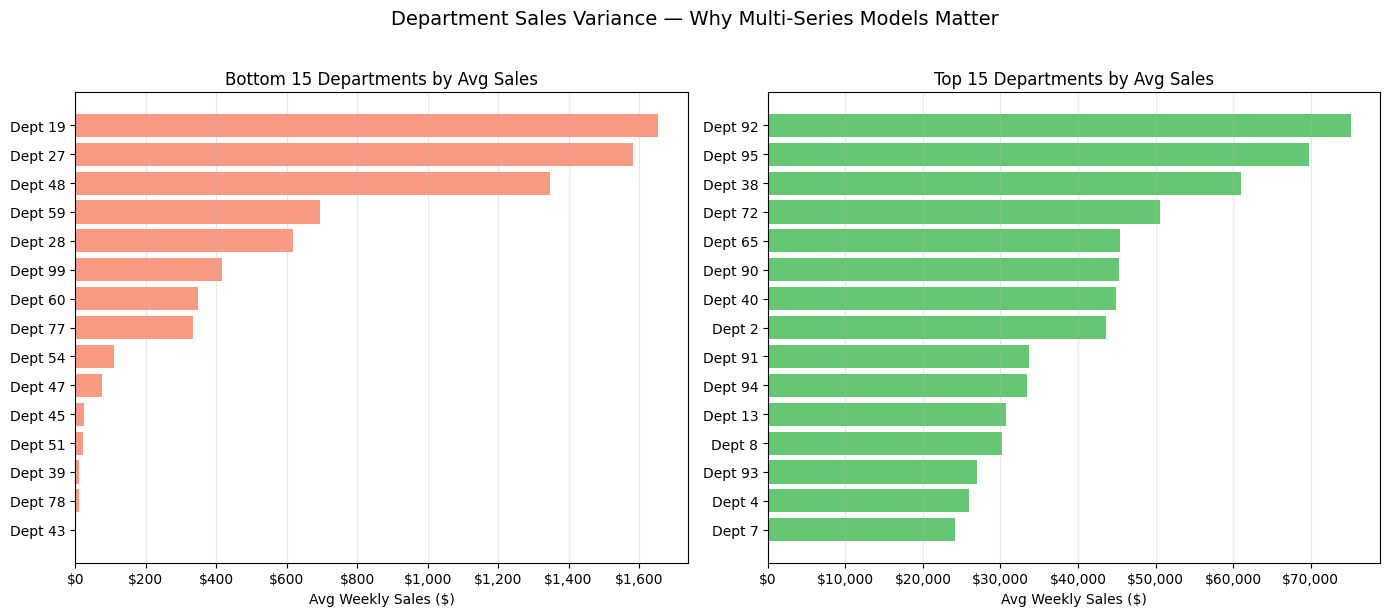

/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils/preprocessing.py
/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils/features.py
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip
Building features
Date features done
Lag features: [1, 2, 4, 52] done
Rolling features: [4, 8, 12] done
Holiday features done
Store/Dept encoding done
Final shape: (536634, 44)
(536634, 44)


,Store,Dept,Date,Weekly_Sales,IsHoliday,IsTestSet,Type,Size,Temperature,Fuel_Price,...,holiday_weight,Holiday_Name,is_super_bowl,is_thanksgiving,is_christmas,is_labor_day,store_type_enc,store_avg_sales,dept_avg_sales,store_dept_avg_sales
0,1,1,2010-02-05,24924.50,0,0,A,151315,42.31,2.572,...,1,None,0,0,0,0,0,21710.929985,19213.485088,22513.322937
1,1,1,2010-02-12,46039.49,1,0,A,151315,38.51,2.548,...,5,Super Bowl,1,0,0,0,0,21710.929985,19213.485088,22513.322937
2,1,1,2010-02-19,41595.55,0,0,A,151315,39.93,2.514,...,1,None,0,0,0,0,0,21710.929985,19213.485088,22513.322937


In [3]:
sys.path.append("/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils")

from preprocessing import load_and_clean_data
from features import generate_features

DATA_DIR = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting"

df = load_and_clean_data(DATA_DIR, include_test=True)
df = generate_features(df, lag_steps=[1, 2, 4, 52], rolling_windows=[4, 8, 12], save_plots=False)

print(df.shape)
df.head(3)

In [4]:
def add_advanced_features(df):
    df = df.copy()

    df['sales_momentum']     = df['sales_lag_1'] - df['sales_lag_4']
    df['sales_momentum_52']  = df['sales_lag_1'] - df['sales_lag_52']

    df['yoy_ratio'] = df['sales_lag_1'] / (df['sales_lag_52'] + 1)

    df['lag1_rolling_mean_4']  = df.groupby(['Store','Dept'])['rolling_mean_4'].shift(1)
    df['lag1_rolling_mean_8']  = df.groupby(['Store','Dept'])['rolling_mean_8'].shift(1)

    df['rolling_ratio_4_12'] = df['rolling_mean_4'] / (df['rolling_mean_12'] + 1)

    df['cv_4'] = df['rolling_std_4'] / (df['rolling_mean_4'] + 1)

    df['size_bin'] = pd.cut(
        df['Size'],
        bins=[0, 100000, 150000, 300000],
        labels=[0, 1, 2]
    ).astype(float)

    md_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
    df['total_markdown'] = df[md_cols].sum(axis=1)
    df['any_markdown']   = (df['total_markdown'] > 0).astype(int)
    df['n_markdowns']    = (df[md_cols] > 0).sum(axis=1)

    df['economic_stress'] = df['Unemployment'] * df['Fuel_Price'] / df['CPI']

    df['store_dept_id'] = df['Store'] * 1000 + df['Dept']

    df['dept_x_holiday'] = df['Dept'] * 10 + df['IsHoliday']

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['is_quarter_end'] = df['month'].isin([3, 6, 9, 12]).astype(int)

    df['weeks_to_christmas'] = (52 - df['week_of_year']).clip(lower=0)

    type_map = {'A': 0, 'B': 1, 'C': 2}
    df['store_type_enc'] = df['Type'].map(type_map)

    return df

train_raw = df[df['IsTestSet'] == 0].copy()
test_raw  = df[df['IsTestSet'] == 1].copy()

train_raw = add_advanced_features(train_raw)
test_raw  = add_advanced_features(test_raw)

print("features added")

features added


In [5]:
FEATURE_COLS = [
    'Store', 'Dept', 'store_dept_id', 'store_type_enc', 'size_bin', 'Size',
    'year', 'month', 'week_of_year', 'quarter', 'day_of_week',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'is_quarter_end', 'weeks_to_christmas',
    'IsHoliday', 'is_super_bowl', 'is_thanksgiving',
    'is_christmas', 'is_labor_day', 'dept_x_holiday',
    'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_lag_52',
    'rolling_mean_4', 'rolling_mean_8', 'rolling_mean_12',
    'rolling_std_4', 'rolling_std_8', 'rolling_std_12',
    'lag1_rolling_mean_4', 'lag1_rolling_mean_8',
    'rolling_ratio_4_12', 'cv_4',
    'sales_momentum', 'sales_momentum_52', 'yoy_ratio',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'total_markdown', 'any_markdown', 'n_markdowns',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'economic_stress',
    'store_avg_sales', 'dept_avg_sales', 'store_dept_avg_sales',
]

def wmae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

train_df = train_raw.dropna(subset=FEATURE_COLS + ['Weekly_Sales'])
train_df = train_df.sort_values('Date').reset_index(drop=True)

X = train_df[FEATURE_COLS]
y = train_df['Weekly_Sales']
w = train_df['holiday_weight']

print(f"Training rows : {len(train_df):,}")
print(f"Features      : {len(FEATURE_COLS)}")
print(f"Test rows     : {len(test_raw):,}")

Training rows : 261,083
Features      : 56
Test rows     : 115,064


In [6]:
mlflow.set_experiment("XGBoost_Training")

with mlflow.start_run(run_name="XGBoost_Cleaning"):
    mlflow.log_params({
        "markdown_imputation":    "fill_zero",
        "lag_steps":              [1, 2, 4, 52],
        "rolling_windows":        [4, 8, 12],
        "nan_strategy":           "drop_rows",
        "negative_sales":         "clip_to_zero",
        "train_rows_after_drop":  len(train_df),
        "n_features":             len(FEATURE_COLS),
        "xgboost_cat_handling":   "label_encoded_numeric",
    })
    mlflow.log_text(
        f"Rows: {len(train_df)}\nFeatures: {len(FEATURE_COLS)}\n"
        f"Date range: {train_df['Date'].min().date()} to {train_df['Date'].max().date()}\n",
        "data_summary.txt"
    )
    print("Cleaning run logged")

2026/07/06 17:02:58 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


Cleaning run logged
🏃 View run XGBoost_Cleaning at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/d2e1a833437446cdb85cf21538338048
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1


In [7]:
BASELINE_PARAMS = {
    'objective':        'reg:absoluteerror',  
    'n_estimators':     300,
    'learning_rate':    0.1,
    'max_depth':        6,
    'verbosity':        0,
    'random_state':     42,
}

tscv = TimeSeriesSplit(n_splits=3)
baseline_scores = []

with mlflow.start_run(run_name="XGBoost_Baseline"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("feature_set", "full_v1")
    mlflow.log_param("cv_folds", 3)
    mlflow.log_param("note", "absolute minimum params — floor score")

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

        model = xgb.XGBRegressor(**BASELINE_PARAMS)
        model.fit(X_tr, y_tr,
                  sample_weight=w_tr,
                  eval_set=[(X_val, y_val)],
                  verbose=False)

        preds = model.predict(X_val)
        score = wmae(y_val.values, preds, w_val.values)
        baseline_scores.append(score)
        mlflow.log_metric("fold_wmae", score, step=fold)
        print(f"  Fold {fold+1} WMAE: {score:,.2f}")

    baseline_mean = np.mean(baseline_scores)
    mlflow.log_metric("mean_cv_wmae", baseline_mean)
    print(f"\nBaseline mean WMAE: {baseline_mean:,.2f}")

  Fold 1 WMAE: 2,452.09
  Fold 2 WMAE: 1,906.66
  Fold 3 WMAE: 1,285.59

Baseline mean WMAE: 1,881.45
🏃 View run XGBoost_Baseline at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/d2fff5e6e90e4577a24ecc5170aebf6e
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1


In [8]:
PARAMS_V2 = {
    'objective':     'reg:absoluteerror',
    'n_estimators':  2000,   
    'learning_rate': 0.05,
    'max_depth':     6,
    'subsample':     0.8,
    'colsample_bytree': 0.8,
    'verbosity':     0,
    'random_state':  42,
}

v2_scores = []

with mlflow.start_run(run_name="XGBoost_EarlyStopping"):
    mlflow.log_params(PARAMS_V2)
    mlflow.log_param("early_stopping_rounds", 50)
    mlflow.log_param("note", "early stopping + proper sample weights")

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

        model = xgb.XGBRegressor(**PARAMS_V2, early_stopping_rounds=50)
        model.fit(X_tr, y_tr,
                  sample_weight=w_tr,
                  eval_set=[(X_val, y_val)],
                  verbose=False)

        best_iter = model.best_iteration
        preds = model.predict(X_val)
        score = wmae(y_val.values, preds, w_val.values)
        v2_scores.append(score)
        mlflow.log_metric("fold_wmae", score, step=fold)
        mlflow.log_metric("best_iteration", best_iter, step=fold)
        print(f"  Fold {fold+1} WMAE: {score:,.2f}  (stopped at tree {best_iter})")

    v2_mean = np.mean(v2_scores)
    mlflow.log_metric("mean_cv_wmae", v2_mean)
    print(f"\nV2 mean WMAE: {v2_mean:,.2f}")
    print(f"Improvement over baseline: {baseline_mean - v2_mean:,.2f}")

  Fold 1 WMAE: 2,408.69  (stopped at tree 623)
  Fold 2 WMAE: 1,831.02  (stopped at tree 247)
  Fold 3 WMAE: 1,267.76  (stopped at tree 693)

V2 mean WMAE: 1,835.82
Improvement over baseline: 45.62
🏃 View run XGBoost_EarlyStopping at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/d98943600eab4751b85f9877ee3ac83a
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1


In [9]:
OBJECTIVES = {
    'reg:absoluteerror':    'MAE loss — directly matches WMAE',
    'reg:squarederror':     'MSE loss — penalizes holiday spikes harder',
    'reg:pseudohubererror': 'Huber loss — robust to return/correction outliers',
}

BASE_PARAMS = {
    'n_estimators':     2000,
    'learning_rate':    0.05,
    'max_depth':        6,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'early_stopping_rounds': 50,
    'verbosity':        0,
    'random_state':     42,
}

objective_results = {}

for obj_name, obj_note in OBJECTIVES.items():
    fold_scores = []
    print(f"\nObjective: {obj_name}")

    with mlflow.start_run(run_name=f"XGBoost_Objective_{obj_name.split(':')[1]}"):
        params = {**BASE_PARAMS, 'objective': obj_name}
        mlflow.log_params(params)
        mlflow.log_param("note", obj_note)

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr,
                      sample_weight=w_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

            preds = model.predict(X_val)
            score = wmae(y_val.values, preds, w_val.values)
            fold_scores.append(score)
            mlflow.log_metric("fold_wmae", score, step=fold)
            print(f"  Fold {fold+1} WMAE: {score:,.2f}")

        mean_score = np.mean(fold_scores)
        mlflow.log_metric("mean_cv_wmae", mean_score)
        objective_results[obj_name] = mean_score
        print(f"  Mean WMAE: {mean_score:,.2f}")

best_objective = min(objective_results, key=objective_results.get)
print(f"\nBest objective: {best_objective} → {objective_results[best_objective]:,.2f}")


Objective: reg:absoluteerror
  Fold 1 WMAE: 2,408.69
  Fold 2 WMAE: 1,831.02
  Fold 3 WMAE: 1,267.76
  Mean WMAE: 1,835.82
🏃 View run XGBoost_Objective_absoluteerror at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/78517acd9bdc457095302c7ede989457
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

Objective: reg:squarederror
  Fold 1 WMAE: 2,336.57
  Fold 2 WMAE: 1,971.03
  Fold 3 WMAE: 1,369.23
  Mean WMAE: 1,892.28
🏃 View run XGBoost_Objective_squarederror at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/59f3f02241194ff2be13f8c1cf43eff8
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

Objective: reg:pseudohubererror
  Fold 1 WMAE: 3,170.67
  Fold 2 WMAE: 2,288.18
  Fold 3 WMAE: 1,586.86
  Mean WMAE: 2,348.57
🏃 View run XGBoost_Objective_pseudohu

In [10]:
TREE_CONFIGS = {
    'shallow_wide': {
        'max_depth': 4, 'max_leaves': 63,
        'note': 'shallow but wide — less overfit risk'
    },
    'medium':       {
        'max_depth': 6, 'max_leaves': 127,
        'note': 'standard depth — good balance'
    },
    'deep':         {
        'max_depth': 8, 'max_leaves': 255,
        'note': 'deep trees — memorizes dept patterns'
    },
    'very_deep':    {
        'max_depth': 10, 'max_leaves': 511,
        'note': 'very deep — likely overfits, useful to confirm'
    },
}

tree_results = {}

for config_name, config in TREE_CONFIGS.items():
    note = config.pop('note')
    fold_scores = []
    print(f"\nConfig: {config_name}")

    params = {
        'objective':         best_objective,
        'n_estimators':      2000,
        'learning_rate':     0.05,
        'subsample':         0.8,
        'colsample_bytree':  0.8,
        'early_stopping_rounds': 50,
        'verbosity':         0,
        'random_state':      42,
        **config,
    }

    with mlflow.start_run(run_name=f"XGBoost_Tree_{config_name}"):
        mlflow.log_params(params)
        mlflow.log_param("note", note)

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr,
                      sample_weight=w_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

            preds = model.predict(X_val)
            score = wmae(y_val.values, preds, w_val.values)
            fold_scores.append(score)
            mlflow.log_metric("fold_wmae", score, step=fold)

        mean_score = np.mean(fold_scores)
        mlflow.log_metric("mean_cv_wmae", mean_score)
        tree_results[config_name] = mean_score
        print(f"  Mean WMAE: {mean_score:,.2f}  ({note})")
        config['note'] = note  # restore

best_tree_config = min(tree_results, key=tree_results.get)
best_tree_params = {k: v for k, v in TREE_CONFIGS[best_tree_config].items() if k != 'note'}
print(f"\nBest tree config: {best_tree_config}")


Config: shallow_wide
  Mean WMAE: 1,850.84  (shallow but wide — less overfit risk)
🏃 View run XGBoost_Tree_shallow_wide at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/f0e7dbef40d34bc1a4dc99929ea48588
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

Config: medium
  Mean WMAE: 1,835.82  (standard depth — good balance)
🏃 View run XGBoost_Tree_medium at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/535f496d2eac4cb187a2c99fc1c586e1
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

Config: deep
  Mean WMAE: 1,817.93  (deep trees — memorizes dept patterns)
🏃 View run XGBoost_Tree_deep at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/5da33c624d62483399cbd67e574cca5d
🧪 View experiment at: https://da

In [11]:
REG_CONFIGS = {
    'no_reg': {
        'alpha': 0, 'reg_lambda': 1, 'gamma': 0, 'min_child_weight': 1,
        'note': 'no regularization — likely overfits'
    },
    'l1_only': {
        'alpha': 1.0, 'reg_lambda': 0, 'gamma': 0, 'min_child_weight': 1,
        'note': 'L1 only — sparse leaf weights'
    },
    'l2_only': {
        'alpha': 0, 'reg_lambda': 5.0, 'gamma': 0, 'min_child_weight': 1,
        'note': 'L2 only — smooth leaf weights'
    },
    'gamma_pruning': {
        'alpha': 0, 'reg_lambda': 1, 'gamma': 1.0, 'min_child_weight': 10,
        'note': 'pruning — only splits that earn their keep'
    },
    'balanced': {
        'alpha': 0.1, 'reg_lambda': 2.0, 'gamma': 0.5, 'min_child_weight': 5,
        'note': 'balanced — all regularization types'
    },
    'strong': {
        'alpha': 2.0, 'reg_lambda': 10.0, 'gamma': 2.0, 'min_child_weight': 20,
        'note': 'strong regularization — conservative model'
    },
}

reg_results = {}

for config_name, config in REG_CONFIGS.items():
    note = config.pop('note')
    fold_scores = []
    print(f"\nReg config: {config_name}")

    params = {
        'objective':         best_objective,
        'n_estimators':      2000,
        'learning_rate':     0.05,
        'subsample':         0.8,
        'colsample_bytree':  0.8,
        'early_stopping_rounds': 50,
        'verbosity':         0,
        'random_state':      42,
        **best_tree_params,
        **config,
    }

    with mlflow.start_run(run_name=f"XGBoost_Reg_{config_name}"):
        mlflow.log_params(params)
        mlflow.log_param("note", note)

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr,
                      sample_weight=w_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

            preds = model.predict(X_val)
            score = wmae(y_val.values, preds, w_val.values)
            fold_scores.append(score)
            mlflow.log_metric("fold_wmae", score, step=fold)

        mean_score = np.mean(fold_scores)
        mlflow.log_metric("mean_cv_wmae", mean_score)
        reg_results[config_name] = mean_score
        print(f"  Mean WMAE: {mean_score:,.2f}  ({note})")
        config['note'] = note

best_reg_config = min(reg_results, key=reg_results.get)
best_reg_params = {k: v for k, v in REG_CONFIGS[best_reg_config].items() if k != 'note'}
print(f"\nBest reg config: {best_reg_config}")


Reg config: no_reg
  Mean WMAE: 1,817.93  (no regularization — likely overfits)
🏃 View run XGBoost_Reg_no_reg at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/8825a0f89bda498c98ab187fab100de1
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

Reg config: l1_only
  Mean WMAE: 1,811.08  (L1 only — sparse leaf weights)
🏃 View run XGBoost_Reg_l1_only at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/9dd0e95c60fe4f2bb710fc46f99dc1f9
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

Reg config: l2_only
  Mean WMAE: 1,823.38  (L2 only — smooth leaf weights)
🏃 View run XGBoost_Reg_l2_only at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/e07e2941fdd8436ca9b3b960f09c8be6
🧪 View experiment at: https://dagsh

In [12]:
SAMPLE_CONFIGS = {
    'no_sampling': {
        'subsample': 1.0, 'colsample_bytree': 1.0,
        'colsample_bylevel': 1.0, 'colsample_bynode': 1.0,
        'note': 'no sampling — deterministic'
    },
    'tree_sampling': {
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'colsample_bylevel': 1.0, 'colsample_bynode': 1.0,
        'note': 'standard — sample rows and cols per tree'
    },
    'aggressive_sampling': {
        'subsample': 0.6, 'colsample_bytree': 0.6,
        'colsample_bylevel': 0.8, 'colsample_bynode': 1.0,
        'note': 'aggressive — more randomness, less overfit'
    },
    'node_sampling': {
        'subsample': 0.8, 'colsample_bytree': 1.0,
        'colsample_bylevel': 1.0, 'colsample_bynode': 0.7,
        'note': 'per-node col sampling — Random Forest style'
    },
}

sample_results = {}

for config_name, config in SAMPLE_CONFIGS.items():
    note = config.pop('note')
    fold_scores = []
    print(f"\nSample config: {config_name}")

    params = {
        'objective':         best_objective,
        'n_estimators':      2000,
        'learning_rate':     0.05,
        'early_stopping_rounds': 50,
        'verbosity':         0,
        'random_state':      42,
        **best_tree_params,
        **best_reg_params,
        **config,
    }

    with mlflow.start_run(run_name=f"XGBoost_Sample_{config_name}"):
        mlflow.log_params(params)
        mlflow.log_param("note", note)

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr,
                      sample_weight=w_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

            preds = model.predict(X_val)
            score = wmae(y_val.values, preds, w_val.values)
            fold_scores.append(score)
            mlflow.log_metric("fold_wmae", score, step=fold)

        mean_score = np.mean(fold_scores)
        mlflow.log_metric("mean_cv_wmae", mean_score)
        sample_results[config_name] = mean_score
        print(f"  Mean WMAE: {mean_score:,.2f}  ({note})")
        config['note'] = note

best_sample_config = min(sample_results, key=sample_results.get)
best_sample_params = {k: v for k, v in SAMPLE_CONFIGS[best_sample_config].items() if k != 'note'}
print(f"\nBest sample config: {best_sample_config}")


Sample config: no_sampling
  Mean WMAE: 1,820.11  (no sampling — deterministic)
🏃 View run XGBoost_Sample_no_sampling at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/a636eb803e4b43d29d62dd0ba8740f38
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

Sample config: tree_sampling
  Mean WMAE: 1,811.08  (standard — sample rows and cols per tree)
🏃 View run XGBoost_Sample_tree_sampling at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/e84ee694e9384c9b9352b563da01c8d2
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

Sample config: aggressive_sampling
  Mean WMAE: 1,865.66  (aggressive — more randomness, less overfit)
🏃 View run XGBoost_Sample_aggressive_sampling at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experim

In [13]:
LR_CONFIGS = {
    'fast':   {'learning_rate': 0.1,  'n_estimators': 500,  'note': 'fast training'},
    'medium': {'learning_rate': 0.05, 'n_estimators': 2000, 'note': 'balanced'},
    'slow':   {'learning_rate': 0.01, 'n_estimators': 5000, 'note': 'slow + many trees'},
    'very_slow': {'learning_rate': 0.005, 'n_estimators': 10000, 'note': 'very slow — max accuracy'},
}

lr_results = {}

for config_name, config in LR_CONFIGS.items():
    note = config.pop('note')
    fold_scores = []
    print(f"\nLR config: {config_name} (lr={config['learning_rate']}, trees={config['n_estimators']})")

    params = {
        'objective':             best_objective,
        'early_stopping_rounds': 100,
        'verbosity':             0,
        'random_state':          42,
        **best_tree_params,
        **best_reg_params,
        **best_sample_params,
        **config,
    }

    with mlflow.start_run(run_name=f"XGBoost_LR_{config_name}"):
        mlflow.log_params(params)
        mlflow.log_param("note", note)

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr,
                      sample_weight=w_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

            preds = model.predict(X_val)
            score = wmae(y_val.values, preds, w_val.values)
            fold_scores.append(score)
            mlflow.log_metric("fold_wmae", score, step=fold)
            mlflow.log_metric("best_iteration", model.best_iteration, step=fold)

        mean_score = np.mean(fold_scores)
        mlflow.log_metric("mean_cv_wmae", mean_score)
        lr_results[config_name] = mean_score
        print(f"  Mean WMAE: {mean_score:,.2f}")
        config['note'] = note

best_lr_config = min(lr_results, key=lr_results.get)
best_lr_params = {k: v for k, v in LR_CONFIGS[best_lr_config].items() if k != 'note'}
print(f"\nBest LR config: {best_lr_config}")


LR config: fast (lr=0.1, trees=500)
  Mean WMAE: 1,860.67
🏃 View run XGBoost_LR_fast at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/4e5413e718cc4ca0ba1d00e77719bd47
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

LR config: medium (lr=0.05, trees=2000)
  Mean WMAE: 1,811.08
🏃 View run XGBoost_LR_medium at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/08d603920ea04b42b2884b579c10e611
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1

LR config: slow (lr=0.01, trees=5000)
  Mean WMAE: 1,808.40
🏃 View run XGBoost_LR_slow at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/a7bf9bd794cc401a89d54dc7514917d4
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.m

In [14]:
def xgb_objective(trial):
    params = {
        'objective':         best_objective,
        'verbosity':         0,
        'random_state':      42,
        'early_stopping_rounds': 50,
        # Tree structure
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'max_leaves':        trial.suggest_int('max_leaves', 31, 511),
        # Learning
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 500, 5000, step=500),
        # Sampling
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode':  trial.suggest_float('colsample_bynode', 0.5, 1.0),
        # Regularization
        'alpha':             trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'gamma':             trial.suggest_float('gamma', 0, 5.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 50),
    }

    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(TimeSeriesSplit(n_splits=2).split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr,
                  sample_weight=w_tr,
                  eval_set=[(X_val, y_val)],
                  verbose=False)

        preds = model.predict(X_val)
        fold_scores.append(wmae(y_val.values, preds, w_val.values))

    return np.mean(fold_scores)

study = optuna.create_study(direction='minimize')
study.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

print(f"\nBest Optuna WMAE: {study.best_value:,.2f}")
print("Best params:", study.best_params)

with mlflow.start_run(run_name="XGBoost_Optuna_Search"):
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_optuna_wmae", study.best_value)
    mlflow.log_param("n_trials", 40)
    mlflow.log_param("objective", best_objective)

    trials_df = study.trials_dataframe()
    trials_df.to_csv("xgb_optuna_trials.csv", index=False)
    mlflow.log_artifact("xgb_optuna_trials.csv", "optuna_results")

OPTUNA_PARAMS = {
    'objective': best_objective,
    'verbosity': 0,
    'random_state': 42,
    **study.best_params
}

  0%|          | 0/40 [00:00<?, ?it/s]


Best Optuna WMAE: 1,784.45
Best params: {'max_depth': 9, 'max_leaves': 158, 'learning_rate': 0.009535348788255502, 'n_estimators': 3000, 'subsample': 0.862179759265693, 'colsample_bytree': 0.8049974253742679, 'colsample_bylevel': 0.9901348299124336, 'colsample_bynode': 0.9959959250894765, 'alpha': 2.392949164628172, 'reg_lambda': 0.007314156650500203, 'gamma': 3.958750205687972, 'min_child_weight': 4}
🏃 View run XGBoost_Optuna_Search at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/408895474956416a81dc60604b782983
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1


In [15]:
tscv5 = TimeSeriesSplit(n_splits=5)
optuna_cv_scores = []

with mlflow.start_run(run_name="XGBoost_Optuna_CV5"):
    mlflow.log_params(OPTUNA_PARAMS)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("source", "optuna_best")

    for fold, (tr_idx, val_idx) in enumerate(tscv5.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        w_tr, w_val = w.iloc[tr_idx], w.iloc[val_idx]

        model = xgb.XGBRegressor(**OPTUNA_PARAMS, early_stopping_rounds=50)
        model.fit(X_tr, y_tr,
                  sample_weight=w_tr,
                  eval_set=[(X_val, y_val)],
                  verbose=False)

        preds = model.predict(X_val)
        score = wmae(y_val.values, preds, w_val.values)
        optuna_cv_scores.append(score)
        mlflow.log_metric("fold_wmae", score, step=fold)
        print(f"  Fold {fold+1} WMAE: {score:,.2f}")

    optuna_mean = np.mean(optuna_cv_scores)
    mlflow.log_metric("mean_cv_wmae", optuna_mean)
    print(f"\nOptuna best 5-fold mean WMAE: {optuna_mean:,.2f}")

  Fold 1 WMAE: 1,347.89
  Fold 2 WMAE: 2,691.45
  Fold 3 WMAE: 1,822.58
  Fold 4 WMAE: 1,412.61
  Fold 5 WMAE: 1,201.49

Optuna best 5-fold mean WMAE: 1,695.20
🏃 View run XGBoost_Optuna_CV5 at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/dedfb1d274564f53be1a8e541f5fc5a2
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1


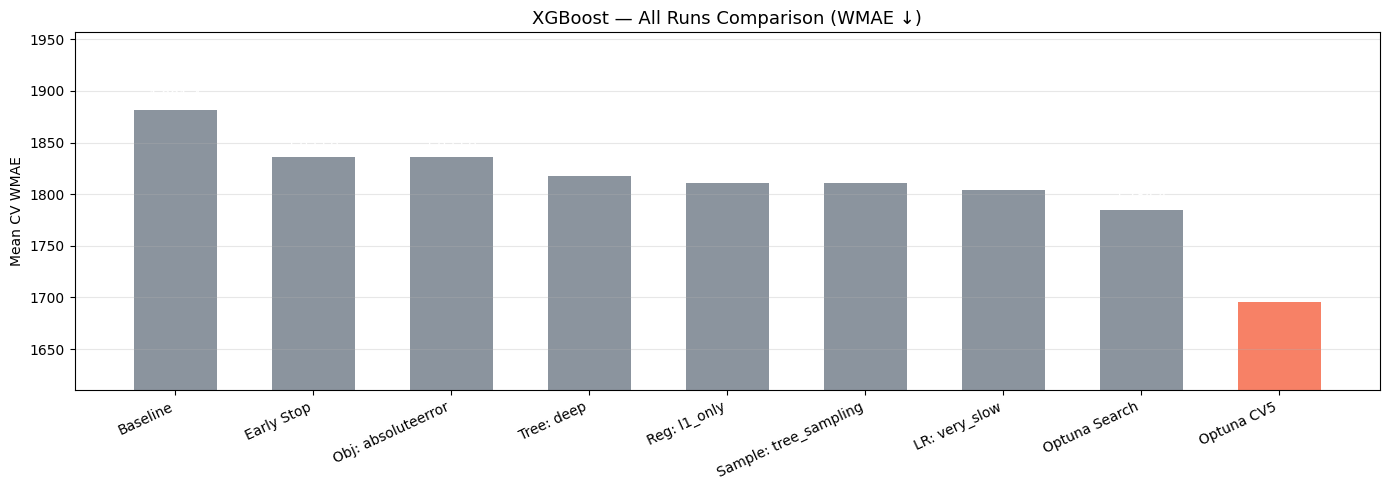


Best run: Optuna CV5 → WMAE 1,695.20
Worst run: Baseline → WMAE 1,881.45
Total improvement: 186.24


In [16]:
all_runs = {
    'Baseline':           np.mean(baseline_scores),
    'Early Stop':         v2_mean,
    f'Obj: {best_objective.split(":")[1]}': min(objective_results.values()),
    f'Tree: {best_tree_config}':            min(tree_results.values()),
    f'Reg: {best_reg_config}':              min(reg_results.values()),
    f'Sample: {best_sample_config}':        min(sample_results.values()),
    f'LR: {best_lr_config}':               min(lr_results.values()),
    'Optuna Search':      study.best_value,
    'Optuna CV5':         optuna_mean,
}

names  = list(all_runs.keys())
scores = list(all_runs.values())
colors = ['#8b949e'] * len(names)
colors[scores.index(min(scores))] = '#f78166'

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, scores, color=colors, edgecolor='none', width=0.6)
ax.bar_label(bars, labels=[f'{v:,.1f}' for v in scores],
             padding=5, fontsize=10, color='white')
ax.set_title('XGBoost — All Runs Comparison (WMAE ↓)', fontsize=13)
ax.set_ylabel('Mean CV WMAE')
ax.set_ylim(min(scores) * 0.95, max(scores) * 1.04)
plt.xticks(rotation=25, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_all_runs.png", dpi=130)
plt.show()

print(f"\nBest run: {names[scores.index(min(scores))]} → WMAE {min(scores):,.2f}")
print(f"Worst run: {names[scores.index(max(scores))]} → WMAE {max(scores):,.2f}")
print(f"Total improvement: {max(scores) - min(scores):,.2f}")

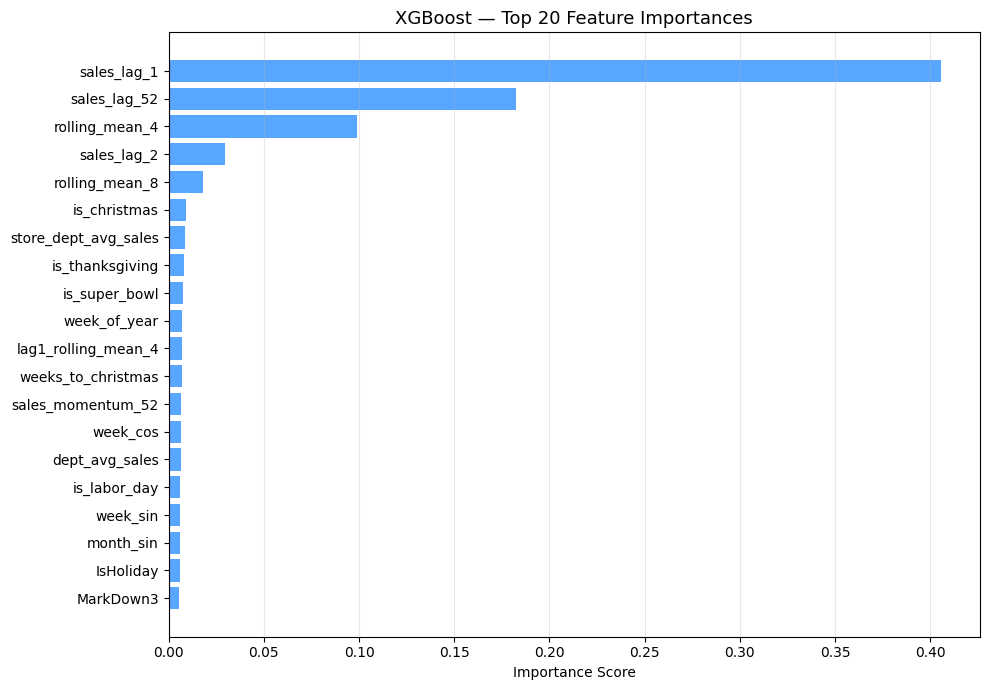

2026/07/06 20:47:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'XGBoost_Walmart_Champion'.
2026/07/06 20:48:15 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_Walmart_Champion, version 1
Created version '1' of model 'XGBoost_Walmart_Champion'.


XGBoost best model registered
Final 5-fold mean WMAE : 1,695.20
Submission rows        : 115,064
🏃 View run XGBoost_Champion at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1/runs/65c085690a4c4627aabd0bd2a7d83163
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/1


In [17]:
champion = xgb.XGBRegressor(**OPTUNA_PARAMS)
champion.fit(X, y, sample_weight=w, verbose=False)

feat_imp = pd.Series(
    champion.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp.index, feat_imp.values, color='#58a6ff', edgecolor='none')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=130)
plt.show()

X_test = test_raw[FEATURE_COLS].copy()
test_preds = np.clip(champion.predict(X_test), 0, None)

submission = pd.DataFrame({
    'Id': test_raw['Store'].astype(str) + '_' +
          test_raw['Dept'].astype(str) + '_' +
          test_raw['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': test_preds
})
submission.to_csv("submission_xgb_champion.csv", index=False)

with mlflow.start_run(run_name="XGBoost_Champion"):
    mlflow.log_params(OPTUNA_PARAMS)
    mlflow.log_metric("mean_cv_wmae", optuna_mean)
    mlflow.log_param("n_features",    len(FEATURE_COLS))
    mlflow.log_param("train_rows",    len(train_df))

    mlflow.xgboost.log_model(
        champion,
        artifact_path="xgb_model",
        registered_model_name="XGBoost_Walmart_Champion"
    )
    mlflow.log_artifact("xgb_all_runs.png",          "plots")
    mlflow.log_artifact("xgb_feature_importance.png", "plots")
    mlflow.log_artifact("submission_xgb_champion.csv", "submissions")

    print("XGBoost best model registered")
    print(f"Final 5-fold mean WMAE : {optuna_mean:,.2f}")
    print(f"Submission rows        : {len(submission):,}")